In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from tbats import TBATS
from sklearn.metrics import mean_squared_error, mean_absolute_error
#from statsforecast import StatsForecast
#from statsforecast.models import AutoTBATS
import warnings
warnings.filterwarnings('ignore')
import re

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Librerías importadas correctamente")

NumPy version: 2.4.6
Pandas version: 3.0.3
Librerías importadas correctamente


In [4]:
ruta_excel_matriz = "./Datos/df_matriz_ventas_articulos_forecast.xlsx"
df=pd.read_excel(ruta_excel_matriz)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigo_articulo           450 non-null    str    
 1   descripcion_completa      449 non-null    str    
 2   grupo_articulo            450 non-null    str    
 3   categoria                 411 non-null    str    
 4   subcategoria              411 non-null    str    
 5   tipo                      406 non-null    str    
 6   marca_fabricante          450 non-null    str    
 7   unidad_medida_inventario  450 non-null    str    
 8   cluster_kmeans_final      448 non-null    float64
 9   descripcion_cluster       448 non-null    str    
 10  venta_2024_01             450 non-null    float64
 11  venta_2024_02             450 non-null    float64
 12  venta_2024_03             450 non-null    float64
 13  venta_2024_04             450 non-null    float64
 14  venta_2024_05        

In [16]:
df.head()

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0


In [20]:
lista_columnas_numericas = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
print(f"Columnas numéricas del DataFrame: {lista_columnas_numericas}")
print(f" longitud de la lista de columnas numéricas: {len(lista_columnas_numericas)}")
lista_col_ventas = [col for col in df.columns if col.startswith('venta_')]
print(f"Columnas de ventas del DataFrame: {lista_col_ventas}")


Columnas numéricas del DataFrame: ['cluster_kmeans_final', 'venta_2024_01', 'venta_2024_02', 'venta_2024_03', 'venta_2024_04', 'venta_2024_05', 'venta_2024_06', 'venta_2024_07', 'venta_2024_08', 'venta_2024_09', 'venta_2024_10', 'venta_2024_11', 'venta_2024_12', 'venta_2025_01', 'venta_2025_02', 'venta_2025_03', 'venta_2025_04', 'venta_2025_05', 'venta_2025_06', 'venta_2025_07', 'venta_2025_08', 'venta_2025_09', 'venta_2025_10', 'venta_2025_11', 'venta_2025_12', 'venta_2026_01', 'venta_2026_02', 'venta_2026_03', 'venta_2026_04', 'venta_2026_05', 'venta_2026_06', 'venta_2026_07']
 longitud de la lista de columnas numéricas: 32
Columnas de ventas del DataFrame: ['venta_2024_01', 'venta_2024_02', 'venta_2024_03', 'venta_2024_04', 'venta_2024_05', 'venta_2024_06', 'venta_2024_07', 'venta_2024_08', 'venta_2024_09', 'venta_2024_10', 'venta_2024_11', 'venta_2024_12', 'venta_2025_01', 'venta_2025_02', 'venta_2025_03', 'venta_2025_04', 'venta_2025_05', 'venta_2025_06', 'venta_2025_07', 'venta_2

In [26]:
df_ventas=df[lista_col_ventas + ["codigo_articulo"]]
df_ventas.set_index("codigo_articulo", inplace=True)
df_ventas.head(10)

,venta_2024_01,venta_2024_02,venta_2024_03,venta_2024_04,venta_2024_05,venta_2024_06,venta_2024_07,venta_2024_08,venta_2024_09,venta_2024_10,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
codigo_articulo,,,,,,,,,,,,,,,,,,,,,
0225-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0,...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
0270H,0.0,0.0,0.0,0.0,10.0,0.0,482.0,0.0,10.0,0.0,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
0384-3M-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
0390H-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
0420H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0
0475-5M,0.0,0.0,0.0,0.0,30.0,0.0,95.0,85.0,0.0,0.0,...,180.0,30.0,0.0,0.0,0.0,0.0,580.0,0.0,0.0,0.0
0475-5M-JASON,0.0,100.0,75.0,30.0,30.0,0.0,30.0,0.0,0.0,0.0,...,150.0,0.0,30.0,0.0,0.0,0.0,22.0,0.0,20.0,0.0
0480-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,20.0,...,0.0,0.0,0.0,80.0,11.0,80.0,0.0,0.0,0.0,0.0
0510H-JASON,164.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,...,0.0,76.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# ============================================================
# 1. Detectar columnas mensuales de venta
# ============================================================

def obtener_columnas_venta_ordenadas(df):
    """
    Detecta columnas tipo venta_YYYY_MM y las ordena cronológicamente.
    """

    patron = r"^venta_\d{4}_\d{2}$"

    columnas_venta = [
        col for col in df.columns
        if re.match(patron, str(col))
    ]

    columnas_venta = sorted(
        columnas_venta,
        key=lambda col: pd.to_datetime(
            col.replace("venta_", "") + "_01",
            format="%Y_%m_%d"
        )
    )

    return columnas_venta


def columna_venta_a_fecha(columna):
    """
    Convierte una columna tipo venta_2024_01 a fecha fin de mes.
    """

    fecha = pd.to_datetime(
        columna.replace("venta_", "") + "_01",
        format="%Y_%m_%d"
    ) + pd.offsets.MonthEnd(0)

    return fecha

In [31]:
columnas_venta = obtener_columnas_venta_ordenadas(df_ventas)

print("Cantidad de columnas de venta:")
print(len(columnas_venta))

print("Primera columna:")
print(columnas_venta[0])

print("Última columna:")
print(columnas_venta[-1])

Cantidad de columnas de venta:
31
Primera columna:
venta_2024_01
Última columna:
venta_2026_07


In [32]:

# 2. Convertir matriz mensual a formato largo
# ============================================================

def convertir_matriz_a_formato_largo(df_ventas, columnas_venta):
    """
    Convierte la matriz mensual por artículo a formato largo:
    codigo_articulo | columna_venta | fecha_mes | venta_mensual
    """

    df_temp = df_ventas.copy()

    if "codigo_articulo" not in df_temp.columns:
        df_temp = df_temp.reset_index()

    columnas_id = [
        col for col in df_temp.columns
        if col not in columnas_venta
    ]

    df_long = df_temp.melt(
        id_vars=columnas_id,
        value_vars=columnas_venta,
        var_name="columna_venta",
        value_name="venta_mensual"
    )

    df_long["fecha_mes"] = df_long["columna_venta"].apply(
        columna_venta_a_fecha
    )

    df_long["venta_mensual"] = pd.to_numeric(
        df_long["venta_mensual"],
        errors="coerce"
    ).fillna(0)

    df_long = df_long.sort_values(
        by=["codigo_articulo", "fecha_mes"]
    ).reset_index(drop=True)

    return df_long

In [35]:
df_series_long = convertir_matriz_a_formato_largo(
    df_ventas=df_ventas,
    columnas_venta=columnas_venta
)

df_series_long.head(31)

,codigo_articulo,columna_venta,venta_mensual,fecha_mes
0,0225-3M,venta_2024_01,0.0,2024-01-31
1,0225-3M,venta_2024_02,0.0,2024-02-29
2,0225-3M,venta_2024_03,0.0,2024-03-31
3,0225-3M,venta_2024_04,0.0,2024-04-30
4,0225-3M,venta_2024_05,0.0,2024-05-31
5,0225-3M,venta_2024_06,0.0,2024-06-30
6,0225-3M,venta_2024_07,0.0,2024-07-31
7,0225-3M,venta_2024_08,18.0,2024-08-31
8,0225-3M,venta_2024_09,0.0,2024-09-30
9,0225-3M,venta_2024_10,0.0,2024-10-31


In [36]:
df_series_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 13950 entries, 0 to 13949
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   codigo_articulo  13950 non-null  str           
 1   columna_venta    13950 non-null  str           
 2   venta_mensual    13950 non-null  float64       
 3   fecha_mes        13950 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 738.0 KB


In [ ]:
df_codigo_ejemplo=df_series_long[df_series_long["codigo_articulo"] == "UCM36LPSS12"]
df_codigo_ejemplo=df_codigo_ejemplo.sort_values(by="fecha_mes").reset_index(drop=True).copy()
df_codigo_ejemplo

,codigo_articulo,columna_venta,venta_mensual,fecha_mes
0,UCM36LPSS12,venta_2024_01,0.0,2024-01-31
1,UCM36LPSS12,venta_2024_02,0.0,2024-02-29
2,UCM36LPSS12,venta_2024_03,4.0,2024-03-31
3,UCM36LPSS12,venta_2024_04,6.0,2024-04-30
4,UCM36LPSS12,venta_2024_05,7.0,2024-05-31
5,UCM36LPSS12,venta_2024_06,0.0,2024-06-30
6,UCM36LPSS12,venta_2024_07,0.0,2024-07-31
7,UCM36LPSS12,venta_2024_08,0.0,2024-08-31
8,UCM36LPSS12,venta_2024_09,4.0,2024-09-30
9,UCM36LPSS12,venta_2024_10,1.0,2024-10-31


Entrenamiento: 24 observaciones (0 a 23)
Prueba: 7 observaciones (24 a 30)


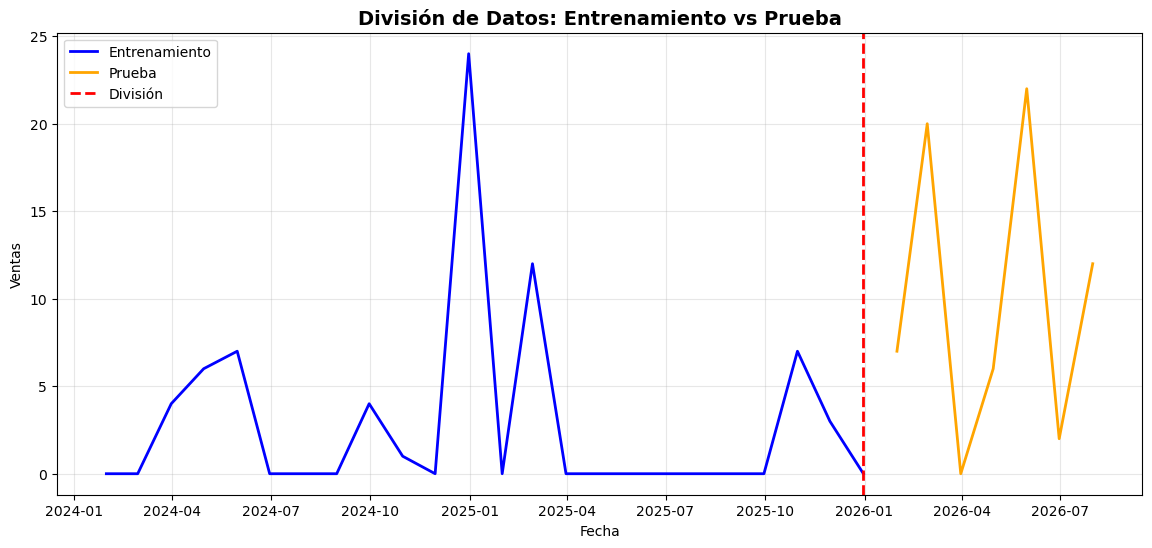

In [45]:
# Dividir en entrenamiento (80%) y prueba (20%)
train_size = int(len(df_codigo_ejemplo) * 0.8)
train_time = df_codigo_ejemplo.iloc[:train_size]['fecha_mes'].values
train_data = df_codigo_ejemplo.iloc[:train_size]['venta_mensual'].values
test_data = df_codigo_ejemplo.iloc[train_size:]['venta_mensual'].values
test_time = df_codigo_ejemplo.iloc[train_size:]['fecha_mes'].values
test_index = df_codigo_ejemplo.iloc[train_size:].index
corte=df_codigo_ejemplo.iloc[train_size-1]['fecha_mes']

print(f"Entrenamiento: {train_size} observaciones ({df_codigo_ejemplo.index[0]} a {df_codigo_ejemplo.index[train_size-1]})")
print(f"Prueba: {len(test_data)} observaciones ({test_index[0]} a {test_index[-1]})")

# Visualizar la división
plt.figure(figsize=(14, 6))
plt.plot(train_time, train_data, label='Entrenamiento', linewidth=2, color='blue')
plt.plot(test_time, test_data, label='Prueba', linewidth=2, color='orange')
plt.axvline(x=corte, color='red', linestyle='--', linewidth=2, label='División')
plt.title('División de Datos: Entrenamiento vs Prueba', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
# ============================================================
# Preparar dataframe para StatsForecast
# ============================================================

df_sf = df_series_long.rename(
    columns={
        "codigo_articulo": "unique_id",
        "fecha_mes": "ds",
        "venta_mensual": "y"
    }
)[["unique_id", "ds", "y"]].copy()

df_sf["ds"] = pd.to_datetime(df_sf["ds"])
df_sf["y"] = pd.to_numeric(df_sf["y"], errors="coerce").fillna(0)

df_sf = df_sf.sort_values(["unique_id", "ds"]).reset_index(drop=True)

df_sf.head()

,unique_id,ds,y
0,0225-3M,2024-01-31,0.0
1,0225-3M,2024-02-29,0.0
2,0225-3M,2024-03-31,0.0
3,0225-3M,2024-04-30,0.0
4,0225-3M,2024-05-31,0.0


In [47]:
# ============================================================
# Separar train/test para evaluación
# ============================================================

horizonte_meses=6

fechas_ordenadas = df_sf["ds"].sort_values().unique()

fechas_test = fechas_ordenadas[-horizonte_meses:]
fechas_train = fechas_ordenadas[:-horizonte_meses]
fecha_inicio_train = fechas_test[0]

df_train = df_sf[df_sf["ds"].isin(fechas_train)].copy()
df_test = df_sf[df_sf["ds"].isin(fechas_test)].copy()

print("Rango de fechas en el conjunto de entrenamiento:")
print(f"  - Inicio: {df_train['ds'].min()}")
print(f"  - Fin: {df_train['ds'].max()}")

print("\nRango de fechas en el conjunto de prueba:")
print(f"  - Inicio: {df_test['ds'].min()}")
print(f"  - Fin: {df_test['ds'].max()}")

Rango de fechas en el conjunto de entrenamiento:
  - Inicio: 2024-01-31 00:00:00
  - Fin: 2026-01-31 00:00:00

Rango de fechas en el conjunto de prueba:
  - Inicio: 2026-02-28 00:00:00
  - Fin: 2026-07-31 00:00:00


In [ ]:
# ============================================================
# Entrenar modelos intermitentes con StatsForecast
# ============================================================

modelos_intermitentes = [
    CrostonClassic(),
    CrostonOptimized(),
    CrostonSBA(),
    IMAPA(),
    TSB(alpha_d=0.1, alpha_p=0.1)
]

sf = StatsForecast(
    models=modelos_intermitentes,
    freq="M",
    n_jobs=-1
)

sf.fit(df=df_train_sf)

df_forecast_intermitente = sf.predict(h=horizonte_meses)

df_forecast_intermitente.head()